In [1]:
#Import some things
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import fits
from astropy.table import Table,join
from astropy.coordinates import SkyCoord
from astropy.io import ascii as asciitable
from unique import unique

In [23]:
seis=Table.read('MeridithRomanApokascCalibtest5.out', format='ascii')
nonseislogg=Table.read('MeridithRomanApokascCalibtest5ns3.out', format='ascii')
nonseisL=Table.read('MeridithRomanApokascCalibLtest5ns3L.out', format='ascii')

In [8]:
#nonseisL

KICID,Mass,Logg,Fe/H,Al/Fe,Teff,C/N,M_err,Logg_err,Fe/H_err,Al/Fe_err,Teff_err,2MASSID,FitML,IntMass,IntAge,IntC12,IntC13,IntN14,IntXsurf
int64,float64,float64,float64,float64,float64,str7,float64,float64,float64,float64,float64,str17,float64,float64,float64,float64,float64,float64,float64
893214,1.534781561666196,1.8168237406095598,-0.2617,0.0815,4718.9233,RGB,1.4404,2.5146,65.58790223050943,0.082389,2.8815,J19245967+3638183,1.9348,1.450819,2.6903,0.001187,4.625e-05,0.0010637,0.70576
1026180,1.269251408771202,1.7302357805275739,0.2741,0.0215,4576.1016,RC,1.5334,2.4512,53.73234326297827,0.085599,1e+20,J19241923+3645378,1.9455,1.746834,1.8707,0.0037078,0.00015046,0.0035867,0.66187
1026309,2.7493790805550327,2.1965514759793265,0.1609,-0.0295,4479.2246,RGB,2.642,2.1176,157.23581496063582,0.047943,0.5842,J19242636+3643594,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
1026452,1.9573936041099025,1.9568231345207774,-0.2652,0.0658,4910.6035,RC,1.4618,2.451,90.536381837271,0.075937,1e+20,J19243452+3647244,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
1027110,1.264623281628865,2.2344615763578597,-0.3017,0.2615,4194.4375,RGB,1.0367,1.6949,171.57799019996384,0.040245,9.0694,J19250937+3644599,1.934,0.980964,11.917,0.0013334,4.2205e-05,0.00065441,0.69628
1027337,1.4642604148040177,1.4326420763739018,0.2081,0.0354,4621.996,RGB,1.2676,2.7732,27.079589486844164,0.123008,5.8519,J19252021+3647118,1.9442,1.267047,5.7807,0.0036355,0.00013129,0.0026018,0.66122
1027707,2.83488831898619,2.829020888431969,0.1105,0.0356,3961.365,RGB,2.0033,1.3484,674.5604715171565,0.018104,1.3052,J19253846+3646103,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5042916,1.6470135833824857,1.715776727664759,-0.014,0.0184,4894.8965,RC,1.8592,2.622,51.97287334516307,0.099585,1e+20,J19562817+4010497,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0


In [24]:
nonseisL=nonseisL[102:202]
nonseislogg=nonseislogg[102:202]
seis=seis[102:202]

In [25]:
nonseisL

KICID,Mass,Logg,Fe/H,Al/Fe,Teff,C/N,M_err,Logg_err,Fe/H_err,Al/Fe_err,Teff_err,2MASSID,FitML,IntMass,IntAge,IntC12,IntC13,IntN14,IntXsurf
int64,float64,float64,float64,float64,float64,str7,float64,float64,float64,float64,float64,str17,float64,float64,float64,float64,float64,float64,float64
1726245,1.8305228687983697,1.760940729719055,0.0813,-0.0087,4814.6533,RC,1.6849,2.5931,57.668775463781955,0.091465,1e+20,J19300260+3715187,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
1726291,1.0432697490591558,1.033357984414494,-0.3795,0.2507,4823.7964,RGB,0.9968,3.0866,10.7983645341408,0.212175,9.7252,J19300513+3717470,1.9324,0.890719,10.023,0.001213,4.3306e-05,0.00043356,0.70332
1864183,0.9799710601693137,1.47462288874237,0.1222,0.0344,4596.487,RGB,1.2393,2.6359,29.827914445199585,0.115914,5.9033,J19215572+3722208,1.9424,1.167325,7.5715,0.0031338,0.00010857,0.0020263,0.67105
1864258,2.4219875121607756e-12,-8.724726886130075,-0.903,0.2925,3806.2642,RGB,1e+20,1e+20,1.8848340285312597e-09,-9999.0,1e+20,J19215994+3721449,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
1864855,1.1774254455577065,1.2718424130808599,-0.0643,0.0276,4899.49,RGB,1.3743,3.0133,18.70003472849456,0.166332,3.6793,J19223280+3720441,1.9387,1.341661,3.9137,0.0019442,7.2554e-05,0.0015394,0.69291
1865262,1.3420440436699,1.5539791085124168,-0.3303,0.1111,4771.19,RGB,1.1431,2.6353,35.80792114927208,0.113988,5.8336,J19225594+3722386,1.9334,1.113036,6.7056,0.0011731,4.0188e-05,0.00074091,0.70426
1865595,1.1692604979605203,2.008614055272858,-0.1648,0.0536,4364.1465,RGB,1.2499,1.9798,102.00326078458369,0.056505,4.7933,J19231500+3723566,1.9367,1.017073,10.459,0.0018073,5.8248e-05,0.00095282,0.69697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2140982,1.2321499291658655,1.7575955002452537,-0.2297,0.0348,4839.2896,RC,1.2355,2.4498,57.22627799384345,0.09276,1e+20,J19042832+3733366,1.9354,1.660777,1.6909,0.0012084,4.9256e-05,0.0012465,0.70941


In [26]:
seis

KICID,Mass,Logg,M_H,alp_M,Teff,C_N,M_err,Logg_err,M_H_err,alp_M_err,Teff_err,TMASSID,IntTeff,IntML,IntAge,IntC12,IntC13,IntN14,IntXsurf
int64,float64,float64,float64,float64,float64,str7,float64,float64,float64,float64,str8,str17,float64,float64,float64,float64,float64,float64,float64
1726245,1.8305228687983697,2.6232,0.0813,-0.0087,4814.6533,RC,1.6849,2.5931,57.668775463781955,0.091465,Gold,J19300260+3715187,4590.8,2.096223,1.4374,0.0023992,9.8748e-05,0.0024895,0.69043
1726291,1.0432697490591558,3.1099,-0.3795,0.2507,4823.7964,RGB,0.9968,3.0866,10.7983645341408,0.212175,Gold,J19300513+3717470,4808.3,1.749194,8.7268,0.0010896,3.5908e-05,0.00058227,0.70331
1864183,0.9799710601693137,2.5576,0.1222,0.0344,4596.487,RGB,1.2393,2.6359,29.827914445199585,0.115914,Gold,J19215572+3722208,4391.1,2.089299,14.548,0.0034533,0.00010836,0.0016768,0.67107
1864258,2.4219875121607756e-12,0.8222,-0.903,0.2925,3806.2642,RGB,1e+20,1e+20,1.8848340285312597e-09,-9999.0,NoDet_OL,J19215994+3721449,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
1864855,1.1774254455577065,2.951,-0.0643,0.0276,4899.49,RGB,1.3743,3.0133,18.70003472849456,0.166332,Gold,J19223280+3720441,4695.9,2.064272,6.3341,0.0020822,7.2873e-05,0.0013913,0.69042
1865262,1.3420440436699,2.6796,-0.3303,0.1111,4771.19,RGB,1.1431,2.6353,35.80792114927208,0.113988,Gold,J19225594+3722386,4723.8,1.798925,3.3904,0.0010534,3.965e-05,0.00087223,0.70623
1865595,1.1692604979605203,2.0102,-0.1648,0.0536,4364.1465,RGB,1.2499,1.9798,102.00326078458369,0.056505,Gold,J19231500+3723566,4295.4,1.843588,6.221,0.0016594,5.808e-05,0.0011173,0.69637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2140982,1.2321499291658655,2.4635,-0.2297,0.0348,4839.2896,RC,1.2355,2.4498,57.22627799384345,0.09276,Gold,J19042832+3733366,4572.0,2.180556,4.796,0.0013969,5.0367e-05,0.0010225,0.70226


In [17]:
#nonseisL=nonseisL[np.where(nonseisL['KICID']<=5078332)]
#nonseislogg=nonseislogg[np.where(nonseislogg['KICID']<=5078332)]
#seis=seis[np.where(seis['KICID']<=5078332)]

In [27]:
#nonseisL

In [28]:
#nonseislogg

In [29]:
#seis

In [30]:
#print(max(nonseisL['KICID']))

In [31]:
good=np.where((nonseisL['C/N']=='RGB') & (nonseisL['IntMass']>0.1) &
             (nonseislogg['IntMass']>0.1) & (seis['Mass']>0.1))

Text(0, 0.5, 'IntMass_Logg')

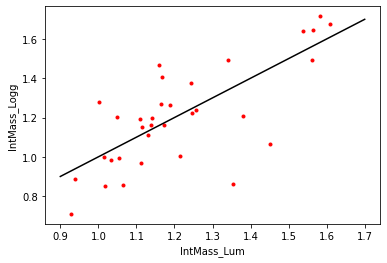

In [36]:
plt.plot(nonseisL['IntMass'][good], nonseislogg['IntMass'][good], 'r.')
plt.plot([0.9, 1.7], [0.9, 1.7], 'k-')
plt.xlabel('IntMass_Lum')
plt.ylabel('IntMass_Logg')

Text(0, 0.5, 'IntMass_Logg')

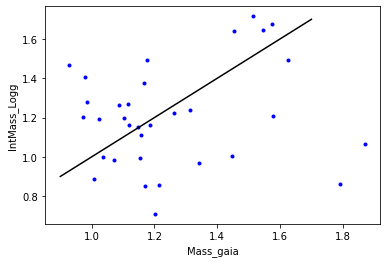

In [37]:
plt.plot(seis['Mass'][good], nonseislogg['IntMass'][good], 'b.')
plt.plot([0.9, 1.7], [0.9, 1.7], 'k-')
plt.xlabel('Mass_gaia')
plt.ylabel('IntMass_Logg')

Text(0, 0.5, 'IntMass_Lum')

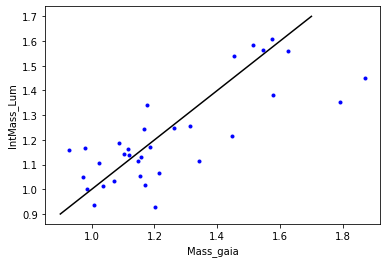

In [38]:
plt.plot(seis['Mass'][good], nonseisL['IntMass'][good], 'b.')
plt.plot([0.9, 1.7], [0.9, 1.7], 'k-')
plt.xlabel('Mass_gaia')
plt.ylabel('IntMass_Lum')